In [9]:
from pyetc_wst import WST
import matplotlib.pyplot as plt
from pyetc_wst.etc import snr_in_window
import numpy as np
wst = WST(log = 'DEBUG', skip_dataload = False)
wst.info()

[DEBUG] WST.__init__ processing time: 12.2973 seconds
[INFO] ETC version 1.5 release date 22 June 2026
[INFO] 	- Fixed bug in _resolve_best_coadd_ifs (IFS COADD_XY="best" mode): replaced the sky-dominated approximation metric fsq/N with the correct full SNR metric signal/sqrt(signal + N²·bg_per_spaxel), where signal = fsq·S and bg_per_spaxel = sky + dark + RON per spaxel at the reference wavelength. The source spectrum is now passed from all three callers (snr_from_source_ifs, _snr_at_wave_ifs, time_from_source_ifs); when no spectrum is available the old approximation is used as fallback.
[INFO] 	- Increased default max_coadd from 20 to 40 for point sources: bad seeing conditions (e.g. 1.5–2") with small spaxels can push the optimal aperture close to or beyond the old cap.
[INFO] 	- For resolved sources, max_coadd is now derived automatically from the extent of the source image (min(ima.shape) // oversamp), removing the artificial fixed ceiling and ensuring the full extent of extended 

In [50]:
tracer = ['BG', 'LRG', 'ELG', 'LBGu', 'LBGg', 'LBGr']
detection_band = ['r', 'z', 'g', 'r', 'i', 'z']
max_mag_desi = [19.5, 21.5, 24.1, 24.2, 24.2, 24.2]
max_mag_wst = [21.7, 22.8, 25.8, 25.5, 25.5, 25.5]
desi_exposure_time = [100, 1000, 1000, 2*60*60, 2*60*60,2*60*60,]
Sdesi = 3.8**2
Swst = 12**2
desi_to_wst_exposure_time = np.array(desi_exposure_time) * Sdesi/Swst
channel = ["yellow",  "red", "green", "green" ,"yellow", "red"]
Lam_Ref = [7000, 6500, 5500, 7000, 7000, 6500]

In [51]:
np.array(desi_to_wst_exposure_time)/3600

array([0.00278549, 0.02785494, 0.02785494, 0.20055556, 0.20055556,
       0.20055556])

In [52]:
def wst_ect(tracer, detection_band,channel, desi_to_wst_exposure_time, Lam_Ref, max_mag_desi):

    base_obs = {"INS": 'moslr',
                "CH": channel,
                "NDIT": 1,
                "DIT": desi_to_wst_exposure_time,#1000,
                "SNR": 0.5,
                "Lam_Ref": Lam_Ref,
                "OBJ_FIB_DISP": 0,
                "SEE": 1.1,
                "GLAO": False,
                "SKYCALC": True,
                "FLI": 0.2,
                "MOON_SEP": 45,
                "AM": 1.1,
                "PMW": 5,
                "Obj_SED": "pl",
                "SED_Name": None,
                "OBJ_MAG": max_mag_desi,
                "MAG_SYS": "AB",
                "MAG_FIL": detection_band+"SDSS",
                "Z": 3,
                "BB_Temp": 9000.0,
                "PL_Index": -2,
                "SEL_FLUX": None,
                "SEL_CWAV": None,
                "SEL_FWHM": None,
                "Obj_Spat_Dis": "ps",
                "IMA": 'sersic',
                "IMA_FWHM": 1.1,
                "IMA_BETA": None,
                "Sersic_Reff": 0.3,
                "Sersic_Ind": 1,
                "COADD_WL": 1,
                "COADD_XY": 1,
                "SNR_RANGE": False,
                "LAM_WIN1": 4000,
                "LAM_WIN2": 10000}
    
    con, ob, spe, im, spe_input = wst.build_obs_full(base_obs)
    return con, ob, spe, im, spe_input


In [53]:
import numpy as np
import math
import matplotlib.pyplot as plt


def t_tel(m,t1exp=15,eta=1.2,Stel=Swst,SNR=10,tref=2*60, mref=24.5, SNRref=10):

    def I(m):#flux as function of magnitude. To be checked.
        I0=1# anyway we will consider ratio of flux
        return I0*10**(-0.4*m)

    x=tref/t1exp *Sdesi/Stel*(I(mref)*SNR/(eta*I(m)*SNRref))**2
    
    return np.array([x_*t1exp for x_ in x]) #ceil is partie entiere sup


In [54]:
SNR_desi_delta = 0.5
dlambda_desi = 0.8 #resolution of the DESI spectrograph
dlambda_wst = 0.5
dLambda = 1370 #size of the r-filter
SNR_desi_Delta = SNR_desi_delta * np.sqrt(dLambda/dlambda_desi)

DESI maximum magnitude
LBGu
809.4367226178282
1143.3419006854951
1623.128902131363
2315.202875884857
3312.431788768238
4753.338604850316
6834.077745449988
9836.395999207309
14173.01396701322
20440.205134132884


(24.2, 26.0)

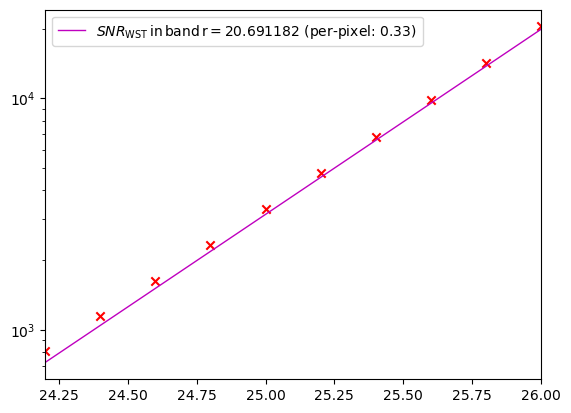

In [55]:
mag = np.linspace(24.2, 26, 10)
for i in range(6):
   if tracer[i] != 'LBGu': continue
   print( 'DESI maximum magnitude')
   print(tracer[i])
   for m in mag:
       con, ob, spe, im, spe_input = wst_ect(tracer[i], detection_band[i], channel[i], 0*desi_to_wst_exposure_time[i], Lam_Ref[i], m)
       snr = SNR_desi_delta * np.sqrt(3/7)
       result = wst.time_from_source_window(con, im, spe,
                                         lam1=1000, lam2=20003,
                                         target_snr=snr,
                                         compute='dit', debug=False)
       print(result['dit'])
       plt.scatter(m, result['dit'], marker = 'x', color = 'r')
       plt.yscale('log')

snr_rband = SNR_desi_delta * np.sqrt(dLambda/dlambda_desi)

y = t_tel(mag,t1exp=15,eta=1,Stel=Swst,SNR=snr_rband, tref=2*60, mref=24.2, SNRref=snr_rband) * 60
plt.plot(mag, y, '-m',
         label=r'$SNR_{\rm WST}\, {\rm in\, band\, r} = $'+f'${snr_rband:0f}$'+ f' (per-pixel: {SNR_desi_delta * np.sqrt(3/7):.2f})', lw=1)

#plt.plot(mag, t_tel(mag,t1exp=15,eta=1,Stel=Swst,SNR = 0.5 * snr_rband,
#                  tref=2*60, mref=24.2,), 'm', SNRref = snr_rband,
#         ,
#         label=r'$SNR_{\rm WST}\, {\rm in\, band\, r} = 20$' + f' (per-pixel: {(20/np.sqrt(dLambda/dlambda_desi * (7/3))):.1f})', lw=1)

plt.legend()
plt.xlim(mag[0], mag[-1])

In [49]:
y

array([  722.        ,  1043.60751448,  1508.47180648,  2180.40514213,
        3151.64430877,  4555.51202715,  6584.71826015,  9517.81365238,
       13757.42638369, 19885.5312381 ])